<a href="https://colab.research.google.com/github/Sean1686/computer_vision/blob/main/menu_detector_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
print('Menu Detector!')

In [ ]:

# -----------------------------
# Import Libraries
# -----------------------------

from google.colab import drive

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torchvision.models import mobilenet_v2

from PIL import Image, UnidentifiedImageError
from torch.utils.data import Dataset, DataLoader

import os
import numpy as np

In [ ]:
drive.mount('/content/drive')

In [ ]:
# Define Dataset Path

DATASET_PATH = '/content/drive/MyDrive/food101_dataset'
print('Dataset_path', DATASET_PATH)

CUSTOM_CLASS_MAPPING = {
    "hamburger": "hamburger",
    "hot_dog": "hot_dog",
    "chocolate_cake": "dessert", # label grouping | class consolidation
    "cheesecake": "dessert",     # label grouping | class consolidation
    "kebab": "kebab",
    "pilaf": "pilaf"
}

CLASSES = ['hamburger', 'hot_dog', 'dessert', 'kebab', 'pilaf']
CLASS_TO_IDX = {cls: i for i, cls in enumerate(CLASSES)}
NUM_CLASSES = len(CLASSES)
print('Class_to_idx', CLASS_TO_IDX)
print('Num_classes', NUM_CLASSES)

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

In [83]:
from PIL.Image import UnidentifiedImageError
#---------------------
# Custom Dataset Class
#---------------------
class FoodDataset(Dataset):
  def __init__(self, images, labels, transform=None):
   self.images = images
   self.labels = labels
   self.transform = transform

  def __len__(self):
    return len(self.images)

  def __getitem__(self, idx):
   img_path = self.images[idx]
   label = self.labels[idx]
   image = Image.open(img_path).convert('RGB')
   if self.transform:
      image = self.transform(image)
   return image, label

In [85]:
#---------------------
# Gather and Split Data
#---------------------

all_images = []
for origin_class, mapped_class in CUSTOM_CLASS_MAPPING.items():
  class_path = os.path.join(DATASET_PATH, origin_class)
  print(f'Checking class path: {class_path}')
  if not os.path.isdir(class_path):
    print(f"Warning: {class_path} is not found. Skipping.")
    continue
  for img_filename in os.listdir(class_path):
    if img_filename.endswith(('.jpg', '.jpeg', '.png')):
       full_path = os.path.join(class_path, img_filename)
       if not os.path.isfile(full_path):
           print(f"Warning: {full_path} is not a file. Skipping.")
           continue
       try:
           # Attempt to open the image to check for corruption
           with Image.open(full_path) as img:
               img.verify() # Verify file integrity
           all_images.append((full_path, CLASS_TO_IDX[mapped_class]))
       except (UnidentifiedImageError, OSError, Exception) as e:
           print(f"Warning: Skipping broken or invalid image: {full_path} - Error: {e}")

# Check if any images were successfully loaded
if not all_images:
    raise ValueError("No valid images found in the dataset. Please check your DATASET_PATH and image files.")

np.random.shuffle(all_images)
split = int(0.8 * len(all_images))
train_data = all_images[:split]
val_data = all_images[split:]

train_images, train_labels = zip(*train_data)
val_images, val_labels = zip(*val_data)

dataset = FoodDataset(train_images, train_labels, transform=transform)
print(f"Number of training images: {len(dataset)}")

# Sample one item from the dataset to ensure it works
if len(dataset) > 0:
    img, lbl = dataset[0]
    print(f"Sample image shape: {img.shape}, Sample label: {lbl}")
else:
    print("Training dataset is empty after filtering.")

Checking class path: /content/drive/MyDrive/food101_dataset/hamburger
Checking class path: /content/drive/MyDrive/food101_dataset/hot_dog
Checking class path: /content/drive/MyDrive/food101_dataset/chocolate_cake
Checking class path: /content/drive/MyDrive/food101_dataset/cheesecake
Checking class path: /content/drive/MyDrive/food101_dataset/kebab
Checking class path: /content/drive/MyDrive/food101_dataset/pilaf
Number of training images: 940
Sample image shape: torch.Size([3, 224, 224]), Sample label: 1


In [86]:

train_dataset = FoodDataset(
    train_images,
    train_labels,
    transform=transform
)

val_dataset = FoodDataset(
    val_images,
    val_labels,
    transform=transform
)


In [87]:

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2
)


In [88]:
# pretrained model
model = mobilenet_v2(weights="IMAGENET1K_V1")

# fine-tuning uchun oxirgi layerni almashtirish
model.classifier[1] = nn.Linear(
    model.classifier[1].in_features,
    NUM_CLASSES
)


In [89]:
device = torch.device(
    'cuda' if torch.cuda.is_available() else 'cpu'
)

print('device', device)

model = model.to(device)


device cpu


In [90]:

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

torch.backends.cudnn.benchmark = True


In [91]:
batch = next(iter(train_loader))

print(type(batch))
print(len(batch))

images, labels = batch

print("images type:", type(images))
print("labels type:", type(labels))

if isinstance(images, (tuple, list)):
    print("images tuple/list length:", len(images))
    print("first image item type:", type(images[0]))

if hasattr(images, "shape"):
    print("images shape:", images.shape)

if hasattr(labels, "shape"):
    print("labels shape:", labels.shape)

print("labels:", labels)


<class 'list'>
2
images type: <class 'torch.Tensor'>
labels type: <class 'torch.Tensor'>
images shape: torch.Size([32, 3, 224, 224])
labels shape: torch.Size([32])
labels: tensor([1, 3, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 4, 1, 4, 1, 4, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1])


In [92]:

''' 8 - TRAINING LOOP & SAVE EFFICIENT AI MODEL '''

NUM_EPOCHS = 2
best_accuracy = 0.0

# Move model to GPU/CPU
model = model.to(device)

for epoch in range(NUM_EPOCHS):

    # -------------------- TRAIN --------------------
    model.train()
    running_loss = 0.0

    for batch_idx, (images, labels) in enumerate(train_loader):

        # Move data to GPU/CPU
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()          # Zero the gradients

        outputs = model(images)        # Forward Pass

        loss = criterion(outputs, labels)  # Calculate Loss

        loss.backward()                # Backpropagation

        optimizer.step()               # Update Weights

        running_loss += loss.item()

        # Show training progress every 10 batches
        if (batch_idx + 1) % 10 == 0:
            print(
                f"Epoch {epoch+1}/{NUM_EPOCHS} | "
                f"Batch {batch_idx+1}/{len(train_loader)} | "
                f"Loss: {loss.item():.4f}"
            )

    # -------------------- VALIDATION --------------------
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    # Calculate Validation Accuracy
    val_acc = 100 * correct / total

    # Print Epoch Result
    print(
        f"\nEpoch [{epoch+1}/{NUM_EPOCHS}] "
        f"Loss: {running_loss / len(train_loader):.4f}, "
        f"Val Accuracy: {val_acc:.2f}%\n"
    )

    # Save Best Model
    if val_acc > best_accuracy:

        best_accuracy = val_acc

        torch.save(model.state_dict(), "/content/menu_detector.pth")

        print(" Saved new best model!\n")


Epoch 1/2 | Batch 10/30 | Loss: 0.3075
Epoch 1/2 | Batch 20/30 | Loss: 0.1755
Epoch 1/2 | Batch 30/30 | Loss: 0.1207


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(



Epoch [1/2] Loss: 0.2884, Val Accuracy: 91.91%

 Saved new best model!

Epoch 2/2 | Batch 10/30 | Loss: 0.0828
Epoch 2/2 | Batch 20/30 | Loss: 0.5218
Epoch 2/2 | Batch 30/30 | Loss: 0.1092


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(



Epoch [2/2] Loss: 0.1202, Val Accuracy: 94.47%

 Saved new best model!



device: cpu
Upload one or more images of your food:


Saving kebab4.webp to kebab4.webp


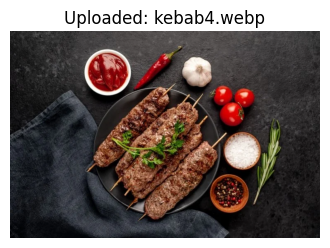

Prediction:
	✅ pilaf: 66.82%
	✅ hot_dog: 16.65%
	✅ kebab: 16.48%
	✅ dessert: 0.03%


In [93]:
import torch
import torchvision.transforms as transforms
from torchvision.models import mobilenet_v2
from PIL import Image
from google.colab import files
import io
import matplotlib.pyplot as plt


''' 1 - DEFINE SEMANTIC CLASSES (LABELS) '''


CLASSES = ['hamburger', 'hot_dog', 'dessert', 'kebab', 'pilaf']  # Must match training order
NUM_CLASSES = len(CLASSES)
CLASS_TO_IDX = {cls: i for i, cls in enumerate(CLASSES)}


''' 2 - TRANSFORM FOR UPLOADED IMAGES '''


transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])


''' 3 - LOADING MODEL '''


model = mobilenet_v2(weights=None)
model.classifier[1] = torch.nn.Linear(model.classifier[1].in_features, NUM_CLASSES)
model.load_state_dict(torch.load('/content/menu_detector.pth', map_location='cpu'))

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

model = model.to(device)
model.eval()


''' 4 - UPLOAD TO PREDICT '''


print("Upload one or more images of your food:")
uploaded = files.upload()

for image_name in uploaded.keys():
    image = Image.open(io.BytesIO(uploaded[image_name])).convert('RGB')

    # Display image
    plt.figure(figsize=(4, 4))
    plt.imshow(image)
    plt.axis('off')
    plt.title(f'Uploaded: {image_name}')
    plt.show()

    # Predict
    image_tensor = transform(image).unsqueeze(0).to(device)
    with torch.no_grad():
        output = model(image_tensor)
        probs = torch.softmax(output, dim=1)[0]
        topk = torch.topk(probs, 4)

    print("Prediction:")
    for i in range(topk.indices.size(0)):
        label = CLASSES[topk.indices[i]]
        confidence = topk.values[i].item() * 100
        print(f"\t✅ {label}: {confidence:.2f}%")